## INSTALL

In [ ]:
import sys

REQUIRED_VERSION = (3, 11, 9)
current_version  = sys.version_info[:3]

if current_version != REQUIRED_VERSION:
    raise RuntimeError(
        f"Wrong Python version. Expected 3.11.9, "
        f"got {'.'.join(str(v) for v in current_version)}. "
        "Make sure the correct kernel is selected."
    )

print(f"Python {'.'.join(str(v) for v in current_version)} OK")

#%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall
#%pip install pandas numpy Pillow tqdm scikit-learn xgboost timm
%pip install timm lightgbm catboost

## IMPORTS

In [12]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    StratifiedKFold, train_test_split,
    cross_val_score, ParameterGrid
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from itertools import product

## MODEL SELECTOR

In [13]:
import os

# Load HF_TOKEN from the .env file in the project root.
# This avoids hardcoding secrets in the notebook.
with open('.env') as env_file:
    for env_line in env_file:
        if '=' in env_line and not env_line.startswith('#'):
            env_key, env_value = env_line.strip().split('=', 1)
            os.environ[env_key] = env_value

print('HF_TOKEN loaded' if os.environ.get('HF_TOKEN') else 'WARNING: HF_TOKEN not found in .env')

HF_TOKEN loaded


In [64]:
# --- Model Selector -----------------------------------------------------------
# DINOv2 ViT-g/14 (Meta, 1536-d) — weights pre-trained on LVD-142M.
# Changing the backbone here requires deleting the cached .pt files so that
# LOAD DATA re-extracts features with the new backbone.
#
FEATURE_EXTRACTOR = 'dinov2'

# Set to True after running the FINE-TUNING cell to use the adapted features
USE_FINETUNED = True

# Cross-validation folds 
N_FOLDS = 5
N_FOLDS_h = 2
# -----------------------------------------------------------------------------

## DEFINITIONS

In [65]:
# --- Device selection ---------------------------------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# --- Load DINOv2 ViT-g/14 backbone -------------------------------------------
# 1536-d feature vectors; weights pre-trained on LVD-142M.
backbone_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitg14')
backbone_model = backbone_model.to(device).eval()

backbone_preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def encode(batch):
    return backbone_model(batch.to(device)).float().cpu()

feat_suffix = '_dinov2'
print(f'Backbone: dinov2  |  suffix: {feat_suffix!r}  |  device: {device}')


# --- Image loading and feature extraction helpers ----------------------------

def save_images(image_dir, output_file, has_labels=True):

    image_tensors = []
    labels        = []
    file_paths    = []

    if has_labels: # train set has labels
        
        # count the classes
        class_names    = sorted(os.listdir(image_dir))
        class_to_index = {name: i for i, name in enumerate(class_names)}
        total_images   = sum(
            len(os.listdir(os.path.join(image_dir, cls)))
            for cls in class_names
            if os.path.isdir(os.path.join(image_dir, cls))
        )
        
        count = 0
        
        # for each class
        for class_name in class_names:
            class_folder = os.path.join(image_dir, class_name)
            
            # for instance in class folder
            for filename in os.listdir(class_folder):
                
                # skip non images
                if not filename.lower().endswith(('.png')):
                    continue
                
                image_path = os.path.join(class_folder, filename)
                
                # open the image and convert to RGB (just incase, idk if supplied images in RGB mode), and use our model's preprocess function
                image_tensors.append(backbone_preprocess(Image.open(image_path).convert('RGB')))
                labels.append(class_to_index[class_name])
                
                file_paths.append(image_path)
                
                count += 1
                print(f'{count}/{total_images}', end='\r')
        
        # save images as one tensor file, makes it easier later
        torch.save({
            'tensors':        torch.stack(image_tensors),
            'labels':         torch.tensor(labels),
            'paths':          file_paths,
            'class_to_index': class_to_index,
        }, output_file)
        
    else: # test set has no assigned labels
        
        # count the images
        image_files  = [
            f for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        total_images = len(image_files)
        
        # for each image
        for i, filename in enumerate(image_files, start=1):
            
            # open the image and convert to RGB (just incase, idk if supplied images in RGB mode), and use our model's preprocess function
            image_path = os.path.join(image_dir, filename)
            image_tensors.append(backbone_preprocess(Image.open(image_path).convert('RGB')))
            
            file_paths.append(image_path)
            
            print(f'{i}/{total_images}', end='\r')
        
        # save image as one tensor file
        torch.save({'tensors': torch.stack(image_tensors), 'paths': file_paths}, output_file)

    print(f'\nSaved {len(image_tensors)} images to {output_file}')


# This function passes every image through our backbone, and saves the feature/embedding vectors
def extract(input_file, output_file):
    
    # load our saved preprocessed images
    data         = torch.load(input_file, weights_only=False)
    images       = data['tensors']
    
    total_images = len(images)
    feature_list = []
    
    # set backbone model to pass forward mode
    with torch.no_grad():
        
        # for every image
        for i, image in enumerate(images, start=1):
            
            # pass image through model
            feature_list.append(encode(image.unsqueeze(0)).squeeze().numpy())
            print(f'{i}/{total_images}', end='\r')
    
    # save the features as one tensor
    features = np.array(feature_list)
    torch.save({**data, 'features': features}, output_file)
    
    print(f'\nExtracted {features.shape} -> saved to {output_file}')

Device: cuda


Using cache found in C:\Users\TheRe/.cache\torch\hub\facebookresearch_dinov2_main


Backbone: dinov2  |  suffix: '_dinov2'  |  device: cuda


In [66]:
# =============================================================================
# METRICS HELPER
# =============================================================================

# Return a dictionary of all the basic metrics
def compute_classification_metrics(true_labels, predicted_labels):
    
    # get number of classes, and number of instances in each class
    unique_classes, samples_per_class = np.unique(true_labels, return_counts=True)
    
    class_balance = {
        int(cls): round(100 * n / len(true_labels), 1)
        for cls, n in zip(unique_classes, samples_per_class)
    }
    
    return {
        'accuracy':      accuracy_score(true_labels, predicted_labels),
        'f1':            f1_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'precision':     precision_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'recall':        recall_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'class_balance': class_balance,
    }

# print the mean +/- std for each metric across all folds
def print_cross_validation_report(model_name, fold_metrics_list):

    print(f'--- {model_name} ---')
    for metric_name in ('accuracy', 'f1', 'precision', 'recall'):
        values     = [m[metric_name] for m in fold_metrics_list]
        mean_value = np.mean(values)
        std_value  = np.std(values)
        print(f'  {metric_name:<9}: {mean_value:.4f} +/- {std_value:.4f}')
    
    print('  class balance:')
    for cls, pct in fold_metrics_list[0]['class_balance'].items():
        print(f'    class {cls}: {pct}%')
    
    print()


# =============================================================================
# MLP MODEL
# =============================================================================

# A simple implementation of an MLP object, we can use different activations and layers and dropouts
class MLP(nn.Module):
    def __init__(self, input_size, num_classes, hidden_layers=(256, 128),
                 activation=nn.ReLU, dropout=0.0):
        
        super().__init__()
        network_layers     = []
        current_layer_size = input_size

        # construct the layers
        for layer_output_size in hidden_layers:
            network_layers.append(nn.Linear(current_layer_size, layer_output_size))
            network_layers.append(activation())
            
            if dropout > 0:
                network_layers.append(nn.Dropout(dropout))
            
            current_layer_size = layer_output_size

        # attach the output layer
        network_layers.append(nn.Linear(current_layer_size, num_classes))
        self.network = nn.Sequential(*network_layers)

    # parse input thru network
    def forward(self, input_tensor):
        return self.network(input_tensor)

# =============================================================================
# CLASSIFIER FUNCTIONS
# =============================================================================


def train_logistic_regression(training_features, training_labels,
                               validation_features, validation_labels,
                               regularisation_strength=1.0):
    
    model = LogisticRegression(C=regularisation_strength, max_iter=2000, random_state=42)
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)


def train_support_vector_machine(training_features, training_labels,
                                  validation_features, validation_labels,
                                  kernel='rbf', regularisation_strength=1.0,
                                  gamma='scale'):
    model = SVC(
        kernel=kernel, C=regularisation_strength, gamma=gamma,
        decision_function_shape='ovr', random_state=42,
    )
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)


def train_random_forest(training_features, training_labels,
                         validation_features, validation_labels,
                         number_of_trees=300):
    model = RandomForestClassifier(
        n_estimators=number_of_trees, max_features='sqrt', random_state=42, n_jobs=12
    )
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)


def train_xgboost_classifier(training_features, training_labels,
                              validation_features, validation_labels):
    model = XGBClassifier(
        objective='multi:softmax', eval_metric='mlogloss', verbosity=0, random_state=42,
    )
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)

# Training of MLP, we use early stopping so we dont overfit and also to cut down training time
def train_multilayer_perceptron(training_features, training_labels,
                                 validation_features, validation_labels,
                                 hidden_layers=(256, 128), activation=nn.ReLU,
                                 dropout=0.0, epochs=30, learning_rate=1e-3):

    compute_device    = 'cuda' if torch.cuda.is_available() else 'cpu'
    number_of_classes = len(np.unique(training_labels))

    # Move data to tensors on the compute device
    training_input     = torch.tensor(np.asarray(training_features,   np.float32)).to(compute_device)
    training_targets   = torch.tensor(np.asarray(training_labels,     np.int64)).to(compute_device)
    validation_input   = torch.tensor(np.asarray(validation_features, np.float32)).to(compute_device)
    validation_targets = torch.tensor(np.asarray(validation_labels,   np.int64)).to(compute_device)

    # Create the loader
    training_data_loader = DataLoader(
        TensorDataset(training_input, training_targets),
        batch_size=512, shuffle=True
    )

    # Create the actual model with a set seed, optimiser and loss function
    torch.manual_seed(42)
    model         = MLP(training_input.shape[1], number_of_classes,
                        hidden_layers, activation, dropout).to(compute_device)
    optimizer     = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.CrossEntropyLoss()

    # variables for early stopping
    best_val_loss              = float('inf')
    best_weights               = None
    epochs_without_improvement = 0

    # training loop
    for epoch in range(epochs):
        
        # Training pass
        model.train()
        for input_batch, target_batch in training_data_loader:
            optimizer.zero_grad()
            loss = loss_function(model(input_batch), target_batch)
            loss.backward()
            optimizer.step()

        # Validation check
        model.eval()
        with torch.no_grad():
            val_loss = loss_function(model(validation_input), validation_targets).item()

        # Save best weights and count how long we've been stuck
        if val_loss < best_val_loss:
            best_val_loss              = val_loss
            best_weights               = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= 25:
                break  # early stopping

    # get best weights
    model.load_state_dict(best_weights)
    model.eval()

    # get our predictions
    with torch.no_grad():
        predictions = model(validation_input).argmax(dim=1).cpu().numpy()

    return model, compute_classification_metrics(validation_labels, predictions)


def train_knn_classifier(training_features, training_labels,
                          validation_features, validation_labels,
                          number_of_neighbours=10, distance_metric='cosine'):
    # Cosine distance is the default because DINOv2/BioCLIP embeddings
    # live on a roughly hyper-spherical surface where cosine similarity works well.
    
    model = KNeighborsClassifier(
        n_neighbors=number_of_neighbours, metric=distance_metric, n_jobs=-1
    )
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)

# =============================================================================
# SHARED PCA PIPELINE HELPER
# =============================================================================

# Fit a scaler and a PCA on train set, then apply them on test set 
def apply_scaler_and_pca(train_feat, val_feat, n_components):
    
    # Standardize
    scaler     = StandardScaler()
    train_feat = scaler.fit_transform(train_feat) # fit
    val_feat   = scaler.transform(val_feat) # apply

    # PCA
    pca        = PCA(n_components=n_components, svd_solver='auto')
    train_feat = pca.fit_transform(train_feat).astype(np.float32) # fit
    val_feat   = pca.transform(val_feat).astype(np.float32) # apply

    return train_feat, val_feat



In [67]:
# =============================================================================
# FINE-TUNE HELPER FUNCTIONS
# =============================================================================
# These are called by finetune() below.  Breaking them out keeps finetune()
# readable and makes each step easy to test or override independently.
# Fine-tuning applies to DINOv2 only; BioCLIP is always frozen.


def _freeze_and_unfreeze_backbone(backbone_model, num_blocks):
    """Freeze all backbone parameters, then unfreeze the last num_blocks
    DINOv2 transformer blocks plus the final norm layer.
    Returns (blocks, norm, num_blocks_used)."""
    for param in backbone_model.parameters():
        param.requires_grad = False

    blocks         = list(backbone_model.blocks)   # 40 transformer blocks
    norm           = backbone_model.norm
    default_blocks = 2   # DINOv2 paper recommendation

    if num_blocks is None:
        num_blocks = default_blocks

    for block in blocks[-num_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in norm.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in backbone_model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in backbone_model.parameters())
    print(f'Trainable: {trainable:,}/{total:,} '
          f'({100*trainable/total:.1f}%)  '
          f'[{num_blocks}/{len(blocks)} blocks unfrozen]')

    return blocks, norm, num_blocks


def _build_prefix_and_suffix(backbone_model, blocks, norm, num_blocks):
    """Build two callables that split DINOv2 at the freeze boundary.

    frozen_prefix_fn(batch) -- patch-embed + frozen transformer blocks.
    trainable_suffix_fn(x)  -- unfrozen blocks + norm -> CLS token (B, 1536).
    """
    def frozen_prefix_fn(batch):
        x = backbone_model.prepare_tokens_with_masks(batch)
        for block in backbone_model.blocks[:-num_blocks]:
            x = block(x)
        return x

    def trainable_suffix_fn(x):
        for block in blocks[-num_blocks:]:
            x = block(x)
        x = norm(x)
        return x[:, 0]   # CLS token -> (B, 1536)

    return frozen_prefix_fn, trainable_suffix_fn


def _cache_frozen_activations(backbone_model, images, frozen_prefix_fn, batch_size, device):
    """Run every image through frozen_prefix_fn once; store in fp16.
    Returns the cached tensor of shape (N, seq_len, d_model)."""
    with torch.no_grad():
        sample_act = frozen_prefix_fn(images[:1].to(device))

    est_gb = sample_act.numel() * len(images) * 2 / 1e9
    print(f'Caching frozen activations (~{est_gb:.1f} GB in fp16)...')

    chunks = []
    backbone_model.eval()
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            chunk = frozen_prefix_fn(images[i:i+batch_size].to(device)).cpu().half()
            chunks.append(chunk)
            print(f'  {min(i+batch_size, len(images))}/{len(images)}', end='\r')

    frozen_cache = torch.cat(chunks)
    del chunks
    print(f'\n  Done. Cache shape: {tuple(frozen_cache.shape)}')
    return frozen_cache


def _extract_via_suffix(source, suffix_fn, use_cache, backbone_model, batch_size, device):
    """Push source through suffix_fn (or backbone_model when not caching).
    Returns a CPU tensor of shape (n_samples, feature_dim)."""
    chunks = []
    with torch.no_grad():
        for i in range(0, len(source), batch_size):
            chunk = source[i:i+batch_size].to(device=device, dtype=torch.float32)
            out   = suffix_fn(chunk) if use_cache else backbone_model(chunk)
            chunks.append(out.cpu())
    return torch.cat(chunks)


def _build_finetune_head(source_sample, suffix_fn, use_cache,
                         backbone_model, num_classes, dropout, device):
    """Infer feature dim via one forward pass, then build a 2-layer head."""
    with torch.no_grad():
        sample      = source_sample[:1].to(device).float()
        feature_dim = (suffix_fn(sample) if use_cache else backbone_model(sample)).shape[-1]
    return nn.Sequential(
        nn.Linear(feature_dim, 512), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(512, num_classes),
    ).to(device)


def _run_finetune_training_loop(backbone_model, head, training_loader,
                                 val_source, labels, val_idx,
                                 suffix_fn, use_cache,
                                 optimizer, loss_fn, grad_scaler,
                                 batch_dtype, use_amp,
                                 device, batch_size, epochs, patience,
                                 trainable_param_names):
    """Train for up to epochs with early stopping; return best state dicts."""
    best_val_loss  = float('inf')
    best_bb_state  = None
    best_hd_state  = None
    no_improve     = 0

    for epoch in range(epochs):
        backbone_model.train()
        head.train()
        for input_batch, target_batch in training_loader:
            input_batch  = input_batch.to(device=device, dtype=batch_dtype)
            target_batch = target_batch.to(device)
            optimizer.zero_grad()
            with torch.autocast('cuda', enabled=use_amp):
                feats      = suffix_fn(input_batch) if use_cache else backbone_model(input_batch)
                batch_loss = loss_fn(head(feats), target_batch)
            grad_scaler.scale(batch_loss).backward()
            grad_scaler.step(optimizer)
            grad_scaler.update()

        backbone_model.eval()
        head.eval()
        val_feats = _extract_via_suffix(
            val_source, suffix_fn, use_cache, backbone_model, batch_size, device
        ).to(device)
        val_loss = loss_fn(head(val_feats), labels[val_idx].to(device)).item()
        print(f'Epoch {epoch+1:>3}/{epochs}  val_loss={val_loss:.4f}', end='\r')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_bb_state = {
                k: v.cpu().clone()
                for k, v in backbone_model.state_dict().items()
                if k in trainable_param_names
            }
            best_hd_state = {k: v.cpu().clone() for k, v in head.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break

    print(f'\nBest val_loss: {best_val_loss:.4f}')
    return best_bb_state, best_hd_state


# =============================================================================
# FINE-TUNE ENTRY POINT
# =============================================================================

def finetune(images_file, train_idx, val_idx, num_classes,
             num_blocks=None, backbone_lr=1e-5, head_lr=1e-3,
             dropout=0.1, epochs=20, batch_size=32,
             patience=5, should_cache_frozen_activations=True):
    """Fine-tune the last num_blocks DINOv2 transformer blocks.

    should_cache_frozen_activations=True  Pre-computes frozen activations once
        (~3 GB fp16), so each training step only runs the small unfrozen suffix
        (~5-10x faster).  Set False only if still OOM.
    num_blocks=None  Uses the DINOv2 default: 4 of 40 blocks.
    """
    print(f'Device: {device}  |  backbone: dinov2  (GPU strongly recommended)')

    data   = torch.load(images_file, weights_only=False, mmap=True)
    images = data['tensors']
    labels = data['labels']

    # Step 1: freeze backbone, unfreeze last num_blocks + norm
    blocks, norm, num_blocks = _freeze_and_unfreeze_backbone(backbone_model, num_blocks)

    # Step 2: build frozen-prefix and trainable-suffix callables
    frozen_prefix_fn, suffix_fn = _build_prefix_and_suffix(
        backbone_model, blocks, norm, num_blocks
    )

    # Step 3: optionally cache frozen activations
    if should_cache_frozen_activations:
        frozen_cache  = _cache_frozen_activations(
            backbone_model, images, frozen_prefix_fn, batch_size, device
        )
        del data, images
        train_dataset = TensorDataset(frozen_cache[train_idx], labels[train_idx])
        val_source    = frozen_cache[val_idx]
        source_sample = frozen_cache
    else:
        train_dataset = TensorDataset(images[train_idx], labels[train_idx])
        val_source    = images[val_idx]
        source_sample = images

    # Step 4: build classification head
    head = _build_finetune_head(
        source_sample, suffix_fn,
        use_cache      = should_cache_frozen_activations,
        backbone_model = backbone_model,
        num_classes    = num_classes,
        dropout        = dropout,
        device         = device,
    )

    # Step 5: optimizer and training utilities
    trainable_param_names = {
        name for name, p in backbone_model.named_parameters() if p.requires_grad
    }
    optimizer = torch.optim.AdamW([
        {'params': [p for p in backbone_model.parameters() if p.requires_grad],
         'lr': backbone_lr},
        {'params': head.parameters(), 'lr': head_lr},
    ], weight_decay=1e-4)

    use_amp      = (device == 'cuda')
    grad_scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)
    batch_dtype  = torch.float16 if use_amp else torch.float32
    loss_fn      = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Step 6: training loop with early stopping
    best_bb_state, best_hd_state = _run_finetune_training_loop(
        backbone_model, head, train_loader,
        val_source, labels, val_idx,
        suffix_fn, use_cache = should_cache_frozen_activations,
        optimizer = optimizer, loss_fn = loss_fn,
        grad_scaler = grad_scaler, batch_dtype = batch_dtype, use_amp = use_amp,
        device = device, batch_size = batch_size, epochs = epochs,
        patience = patience, trainable_param_names = trainable_param_names,
    )

    # Step 7: restore best weights and get final predictions
    current_state = backbone_model.state_dict()
    current_state.update({k: v.to(device) for k, v in best_bb_state.items()})
    backbone_model.load_state_dict(current_state)
    head.load_state_dict({k: v.to(device) for k, v in best_hd_state.items()})

    backbone_model.eval()
    head.eval()
    val_preds = head(
        _extract_via_suffix(
            val_source, suffix_fn, should_cache_frozen_activations,
            backbone_model, batch_size, device
        ).to(device)
    ).argmax(dim=1).cpu().numpy()

    for param in backbone_model.parameters():
        param.requires_grad = False

    return head, compute_classification_metrics(labels[val_idx].numpy(), val_preds)

## FINE-TUNING
Optionally fine-tune the last few DINOv2 transformer blocks on your data,
then re-extract features with the adapted backbone.
Skip this section if you want to use frozen features only.

In [36]:

raw_pt      = torch.load(f'Data\\task1_data\\t1_train_features{feat_suffix}.pt', weights_only=False) # the vector embeddings of the images
num_classes = len(np.unique(raw_pt['labels'].numpy()))
all_idx     = np.arange(len(raw_pt['labels']))

# split train/val
train_idx_ft, val_idx_ft = train_test_split(
    all_idx, test_size=0.2, random_state=42,
    stratify=raw_pt['labels'].numpy()
)

fine_tuned_head, ft_metrics = finetune(
    images_file = f'Data\\task1_data\\t1_train_features{feat_suffix}.pt',
    train_idx   = train_idx_ft,
    val_idx     = val_idx_ft,
    num_classes = num_classes,
    num_blocks  = 4,
    backbone_lr = 1e-5,
    head_lr     = 1e-3,
    dropout     = 0.1,
    epochs      = 20,
    batch_size  = 16,    # be careful with this, depending on RAM/VRAM you could either crash the cell or spend an eternity waiting             
    should_cache_frozen_activations = True,   # just keep this on, its a godsend
)

print(f'Fine-tuned val:  F1={ft_metrics["f1"]:.4f}  Acc={ft_metrics["accuracy"]:.4f}')
print('\nRe-extracting features with fine-tuned backbone...')

extract(f'Data\\task1_data\\t1_train_features{feat_suffix}.pt', f'Data\\task1_data\\t1_train_features_ft{feat_suffix}.pt')
extract(f'Data\\task1_data\\t1_test_features{feat_suffix}.pt',  f'Data\\task1_data\\t1_test_features_ft{feat_suffix}.pt')

print('Done. Set USE_FINETUNED = True in the LOAD DATA cell to use these features.')

Device: cuda  |  backbone: dinov2  (GPU strongly recommended)
Trainable: 113,349,632/1,136,480,768 (10.0%)  [4/40 blocks unfrozen]
Caching frozen activations (~3.0 GB in fp16)...
  3750/3750
  Done. Cache shape: (3750, 257, 1536)
Epoch   8/20  val_loss=0.0802
Early stopping at epoch 8

Best val_loss: 0.0756
Fine-tuned val:  F1=0.9880  Acc=0.9880

Re-extracting features with fine-tuned backbone...
3750/3750
Extracted (3750, 1536) -> saved to Data\task1_data\t1_train_features_ft_dinov2.pt
1250/1250
Extracted (1250, 1536) -> saved to Data\task1_data\t1_test_features_ft_dinov2.pt
Done. Set USE_FINETUNED = True in the LOAD DATA cell to use these features.


## LOAD DATA

In [68]:
# =============================================================================
# LOAD DATA
# =============================================================================
# Saves images and extracts backbone features on first run, then loads from
# .pt cache files on every subsequent run.

train_image_dir = r'Data\task1_data\images\train'
test_image_dir  = r'Data\task1_data\images\test'

if not os.path.exists(train_image_dir):
    raise FileNotFoundError(f'Training folder not found: {train_image_dir}')
if not os.path.exists(test_image_dir):
    raise FileNotFoundError(f'Test folder not found: {test_image_dir}')


# --- Helper: build all .pt cache file paths ----------------------------------

# return a dict of all cache paths of the current config (what model and if finetuned)
def _build_data_paths(suffix, ft_tag):
    base = 'Data\\task1_data\\'
    return {
        'train_images': f'{base}t1_train_images{suffix}.pt',
        'test_images':  f'{base}t1_test_images{suffix}.pt',
        'train_feat':   f'{base}t1_train_features{ft_tag}{suffix}.pt',
        'test_feat':    f'{base}t1_test_features{ft_tag}{suffix}.pt',
    }


# --- Helper: create DINOv2 image/feature caches if missing ------------------

# Function that ensures that our backbone model files exist, if they dont we create them
def _ensure_base_caches(paths):

    if not os.path.exists(paths['train_images']):
        save_images(train_image_dir, paths['train_images'], has_labels=True)

    if not os.path.exists(paths['test_images']):
        save_images(test_image_dir, paths['test_images'], has_labels=False)

    if not os.path.exists(paths['train_feat']):
        extract(paths['train_images'], paths['train_feat'])

    if not os.path.exists(paths['test_feat']):
        extract(paths['test_images'], paths['test_feat'])


# =============================================================================
# Run the data pipeline
# =============================================================================

# are we using finetuned or not?
finetune_tag = '_ft' if USE_FINETUNED else ''
_paths       = _build_data_paths(feat_suffix, finetune_tag)

_ensure_base_caches(_paths)


# --- Load DINOv2 features ----------------------------------------------------

train_data = torch.load(_paths['train_feat'], weights_only=False)
test_data  = torch.load(_paths['test_feat'],  weights_only=False)

train_features = train_data['features']        # shape: (N, D)
train_labels   = train_data['labels'].numpy()  # shape: (N,)
test_features  = test_data['features']         # shape: (M, D) — no labels

print(f'Train: {train_features.shape}  Labels: {train_labels.shape}')
print(f'Test (submission): {test_features.shape}')
print(f'Classes: {train_data["class_to_index"]}')

# Stratified 80/20 split, stratify ensures class proportions are preserved in both halves.
# while the data is already even in balance, its good practice to account for
(   training_split_features,
    validation_split_features,
    training_split_labels,
    validation_split_labels,
) = train_test_split(
    train_features,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels,
)

print(f'\nTraining split:   {training_split_features.shape}')
print(f'Validation split: {validation_split_features.shape}')

Train: (3750, 1536)  Labels: (3750,)
Test (submission): (1250, 1536)
Classes: {'bird': 0, 'butterfly': 1, 'cat': 2, 'deer': 3, 'dog': 4, 'elephant': 5, 'frog': 6, 'horse': 7, 'sheep': 8, 'spider': 9}

Training split:   (3000, 1536)
Validation split: (750, 1536)


## HYPER PARAM SEARCH

In [54]:
# =============================================================================
# HYPER PARAM SEARCH  (N_FOLDS-fold OOF cross-validation)
# =============================================================================
# Each candidate is evaluated with N_FOLDS-fold stratified CV on the full
# training set.  sklearn estimators are cloned per fold so folds never share
# state.  MLP candidates are passed as dicts and call train_multilayer_perceptron
# per fold.
#
# Prerequisite: run LOAD DATA first (populates train_features / train_labels).

SEARCH_LOGREG = True
SEARCH_KNN    = True
SEARCH_SVM    = True
SEARCH_MLP    = True   # expensive — disable for quick runs

from sklearn.base import clone


# --- Core OOF evaluator ------------------------------------------------------

def cross_val_f1(model_or_params, features, labels, n_folds=N_FOLDS_h):
    """N-fold stratified OOF cross-validation.

    sklearn estimators are cloned per fold (no shared state).
    MLP candidates: pass a dict with keys 'type'='mlp', 'hidden', 'activation',
                    'dropout', 'lr'.
    Returns (mean_f1, std_f1) across all folds.
    """
    kfold    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_f1s = []

    for fold_train_idx, fold_val_idx in kfold.split(features, labels):
        fold_train     = features[fold_train_idx]
        fold_val       = features[fold_val_idx]
        fold_train_lbl = labels[fold_train_idx]
        fold_val_lbl   = labels[fold_val_idx]

        if isinstance(model_or_params, dict) and model_or_params.get('type') == 'mlp':
            p = model_or_params
            _, met = train_multilayer_perceptron(
                fold_train, fold_train_lbl, fold_val, fold_val_lbl,
                hidden_layers = p['hidden'],
                activation    = p.get('activation', nn.ReLU),
                dropout       = p.get('dropout',    0.0),
                learning_rate = p.get('lr',         1e-3),
                epochs=25
            )
            fold_f1s.append(met['f1'])
        else:
            m = clone(model_or_params)
            m.fit(np.asarray(fold_train), np.asarray(fold_train_lbl))
            preds = m.predict(np.asarray(fold_val))
            fold_f1s.append(
                f1_score(fold_val_lbl, preds, average='weighted', zero_division=0)
            )

    return float(np.mean(fold_f1s)), float(np.std(fold_f1s))


# --- Build candidate list ----------------------------------------------------

def build_search_candidates():
    """Build (label, model_or_params) pairs for all enabled model families."""
    candidates = []

    if SEARCH_LOGREG:
        for C in [0.001, 0.01, 0.1, 1, 10, 100]:
            candidates.append((
                f'LogReg C={C}',
                LogisticRegression(C=C, max_iter=2000, random_state=42),
            ))

    if SEARCH_KNN:
        for k in [5, 10, 15, 20]:
            for metric in ['cosine', 'euclidean']:
                candidates.append((
                    f'kNN k={k} {metric}',
                    KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=8),
                ))

    if SEARCH_SVM:
        svm_grid = [
            {'kernel': ['linear'],  'C': [ 0.01, 0.1, 1, 10, 100]},
            {'kernel': ['rbf'],     'C': [0.01, 0.1, 1, 10, 100],
                                      'gamma': ['scale', 'auto']}
        ]
        for p in ParameterGrid(svm_grid):
            label = '  '.join(f'{k}={v}' for k, v in sorted(p.items()))
            candidates.append((
                f'SVM {label}',
                SVC(decision_function_shape='ovr', random_state=42, **p),
            ))

    if SEARCH_MLP:
        layer_sizes = [512, 1024, 2048]
        mlp_configs = []
        
        for size in layer_sizes:
            mlp_configs.append((size,))
            
        for h1 in layer_sizes:
            for h2 in layer_sizes:
                mlp_configs.append((h1, h2))
                    
        for hidden in mlp_configs:
            for lr in [1e-2, 1e-4]:
                for dropout in [0.0, 0.2, 0.4]:
                    for activation in [nn.ReLU, nn.GELU]:
                        candidates.append((
                            f'MLP {hidden} lr={lr} do={dropout} act={activation.__name__}',
                            {'type': 'mlp', 'hidden': hidden, 'lr': lr, 'dropout': dropout, 'activation': activation},
                        ))

    return candidates


# --- Run search and collect results ------------------------------------------

def run_hyperparameter_search(features, labels, candidates):
    """Evaluate every candidate with N_FOLDS-fold OOF CV.
    Prints running progress and returns a DataFrame sorted by mean_f1 descending."""
    results = []
    n_cands = len(candidates)
    print(f'\nSearching {n_cands} candidates ({len(labels)} samples, {N_FOLDS_h}-fold CV)')

    for i, (label, model_or_params) in enumerate(candidates, 1):
        mean_f1, std_f1 = cross_val_f1(model_or_params, features, labels)
        print(f'  [{i:>3}/{n_cands}] {label:<55}  F1={mean_f1:.4f} +/- {std_f1:.4f}')
        results.append({'model': label, 'mean_f1': mean_f1, 'std_f1': std_f1})

    return pd.DataFrame(results).sort_values('mean_f1', ascending=False)


# =============================================================================
# Run the search
# =============================================================================

all_features = np.asarray(train_features)
all_labels   = np.asarray(train_labels)

candidates  = build_search_candidates()
results_df  = run_hyperparameter_search(all_features, all_labels, candidates)

fine_tuning_suffix = 'ft' if USE_FINETUNED else 'noft'
csv_path = f'Data/task1_data/search_results_{FEATURE_EXTRACTOR}_{fine_tuning_suffix}.csv'
results_df.to_csv(csv_path, index=False)

print(f'\nTop 20 results:')
print(results_df.head(20).to_string(index=False))
print(f'\nFull results saved to {csv_path}')


Searching 173 candidates (3750 samples, 2-fold CV)
  [  1/173] LogReg C=0.001                                           F1=0.9899 +/- 0.0000
  [  2/173] LogReg C=0.01                                            F1=0.9912 +/- 0.0003
  [  3/173] LogReg C=0.1                                             F1=0.9909 +/- 0.0005
  [  4/173] LogReg C=1                                               F1=0.9912 +/- 0.0003
  [  5/173] LogReg C=10                                              F1=0.9912 +/- 0.0003
  [  6/173] LogReg C=100                                             F1=0.9912 +/- 0.0003
  [  7/173] kNN k=5 cosine                                           F1=0.9848 +/- 0.0003
  [  8/173] kNN k=5 euclidean                                        F1=0.9806 +/- 0.0018
  [  9/173] kNN k=10 cosine                                          F1=0.9832 +/- 0.0003
  [ 10/173] kNN k=10 euclidean                                       F1=0.9793 +/- 0.0010
  [ 11/173] kNN k=15 cosine                     

## SUBMISSION

In [62]:
# --- Settings ----------------------------------------------------------------
# Choose a model and paste in the best params from the search above.
SUBMISSION_MODEL = 'mlp'   # 'linear' | 'svm' | 'knn' | 'xgboost' | 'lgbm' | 'catboost' | 'mlp' | 'stack'

LIN_C = 0.01

SVM_SUBMISSION_PARAMS        = {'kernel': 'rbf', 'C': 1, 'gamma': 0.01}
KNN_NEIGHBOURS               = 10
KNN_DISTANCE_METRIC          = 'cosine'
LIGHTGBM_SUBMISSION_PARAMS   = {'n_estimators': 500, 'num_leaves': 63, 'learning_rate': 0.05}
CATBOOST_SUBMISSION_PARAMS   = {'iterations': 500, 'depth': 6, 'learning_rate': 0.05}

MLP_SUBMISSION_HIDDEN_LAYERS  = (2048,)
MLP_SUBMISSION_DROPOUT_RATE   = 0.0
MLP_SUBMISSION_EPOCHS         = 500
MLP_SUBMISSION_LEARNING_RATE  = 0.0001
MLP_ACTIVATION = nn.GELU
# -----------------------------------------------------------------------------

all_training_features    = np.asarray(train_features, np.float64)
all_training_labels      = np.asarray(train_labels,   np.int64)
test_submission_features = np.asarray(test_features,  np.float64)

print(f'Training {SUBMISSION_MODEL} on all {len(all_training_features)} labelled samples...')

if SUBMISSION_MODEL == 'linear':
    model = LogisticRegression(max_iter=2000, random_state=42, C=LIN_C)
    model.fit(all_training_features, all_training_labels)
    predictions = model.predict(test_submission_features)

elif SUBMISSION_MODEL == 'svm':
    model = SVC(decision_function_shape='ovr', random_state=42, **SVM_SUBMISSION_PARAMS)
    model.fit(all_training_features, all_training_labels)
    predictions = model.predict(test_submission_features)

elif SUBMISSION_MODEL == 'knn':
    model = KNeighborsClassifier(n_neighbors=KNN_NEIGHBOURS, metric=KNN_DISTANCE_METRIC, n_jobs=-1)
    model.fit(all_training_features, all_training_labels)
    predictions = model.predict(test_submission_features)

elif SUBMISSION_MODEL == 'xgboost':
    model = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', verbosity=0, random_state=42)
    model.fit(all_training_features, all_training_labels)
    predictions = model.predict(test_submission_features)

elif SUBMISSION_MODEL == 'mlp':
    # Hold out 5% for early stopping
    holdout_training_features, holdout_validation_features, holdout_training_labels, holdout_validation_labels = train_test_split(
        train_features, train_labels, test_size=0.05, random_state=42, stratify=train_labels
    )
    model, _ = train_multilayer_perceptron(
        holdout_training_features, holdout_training_labels,
        holdout_validation_features, holdout_validation_labels,
        hidden_layers=MLP_SUBMISSION_HIDDEN_LAYERS,
        dropout=MLP_SUBMISSION_DROPOUT_RATE,
        epochs=MLP_SUBMISSION_EPOCHS,
        learning_rate=MLP_SUBMISSION_LEARNING_RATE,
        activation=MLP_ACTIVATION
    )
    
    model.eval()
    
    with torch.no_grad():
        mlp_inference_device  = next(model.parameters()).device
        test_features_tensor  = torch.tensor(np.asarray(test_features, np.float32)).to(mlp_inference_device)
        predictions           = model(test_features_tensor).argmax(dim=1).cpu().numpy()

image_ids  = [os.path.splitext(os.path.basename(path))[0] for path in test_data['paths']]
submission = pd.DataFrame({'image_id': image_ids, 'class_id': predictions})

submission.to_csv('t1_submission.csv', index=False)
print(f'Saved {len(submission)} predictions to t1_submission.csv')

Training mlp on all 3750 labelled samples...
Saved 1250 predictions to t1_submission.csv


## ERROR ANALYSIS

[error analysis] Fine-tuned features — eval on val_idx_ft only (no gradient leakage)
Error analysis  model=mlp  (fine-tune val split  n=750)
  F1=0.9907  Acc=0.9907


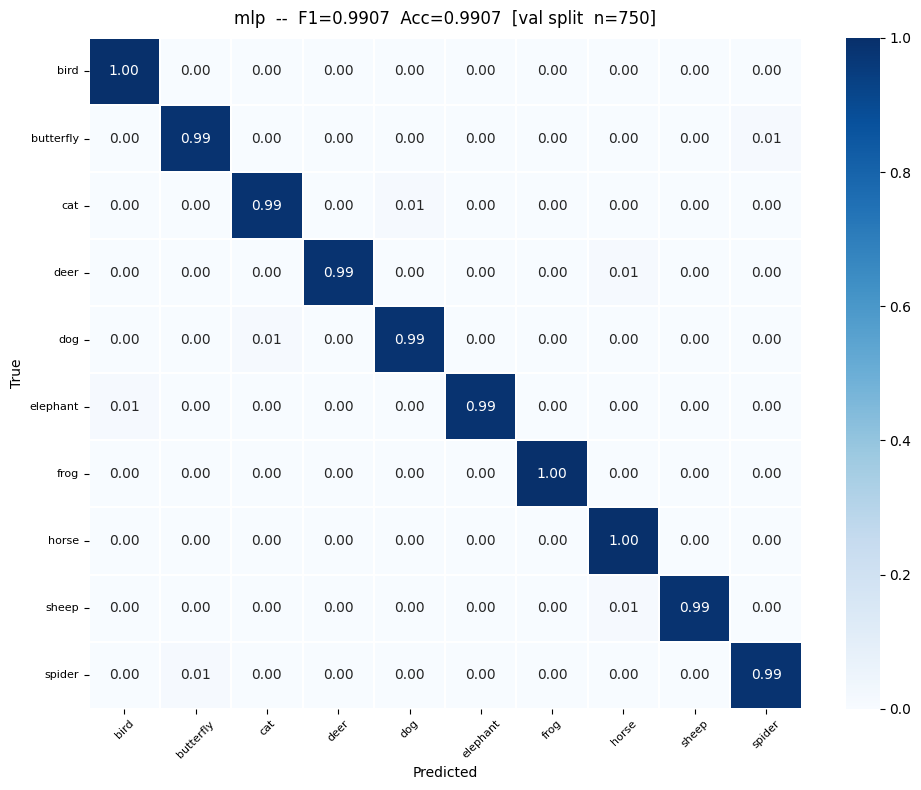


  PER-CLASS F1  (worst -> best)
  Class                               F1   Support
  ---------------------------------------------------
  butterfly                       0.9867        75
  cat                             0.9867        75
  dog                             0.9867        75
  spider                          0.9867        75
  horse                           0.9868        75
  deer                            0.9933        75
  elephant                        0.9933        75
  sheep                           0.9933        75
  bird                            0.9934        75
  frog                            1.0000        75

  Class: butterfly                     F1=0.9867  errors=1/75
  Confusion row  (total=75):
    OK  butterfly                      74x
    XX  spider                          1x



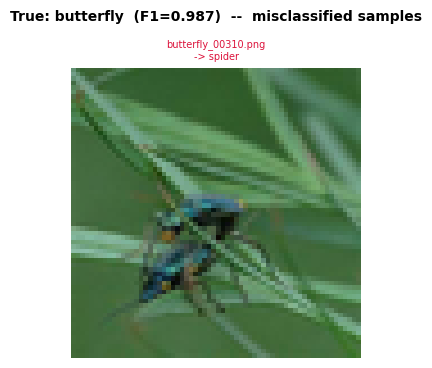


  Class: cat                           F1=0.9867  errors=1/75
  Confusion row  (total=75):
    OK  cat                            74x
    XX  dog                             1x



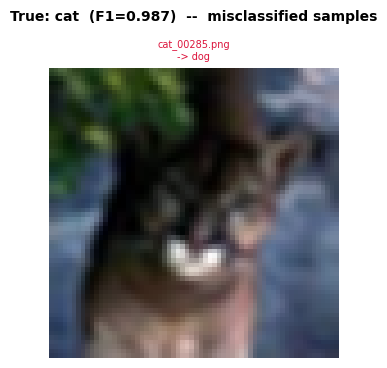


  Class: dog                           F1=0.9867  errors=1/75
  Confusion row  (total=75):
    OK  dog                            74x
    XX  cat                             1x



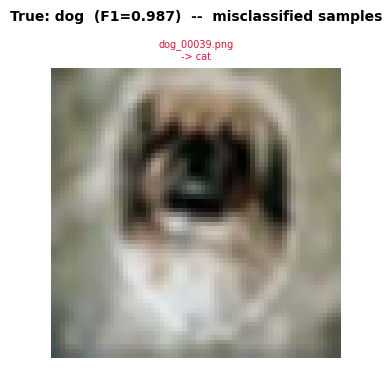


  Class: spider                        F1=0.9867  errors=1/75
  Confusion row  (total=75):
    OK  spider                         74x
    XX  butterfly                       1x



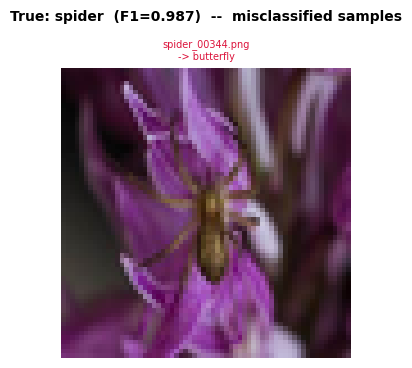


  Class: horse                         F1=0.9868  errors=0/75
  :)  Model got every sample in this class correct!

  Class: deer                          F1=0.9933  errors=1/75
  Confusion row  (total=75):
    OK  deer                           74x
    XX  horse                           1x



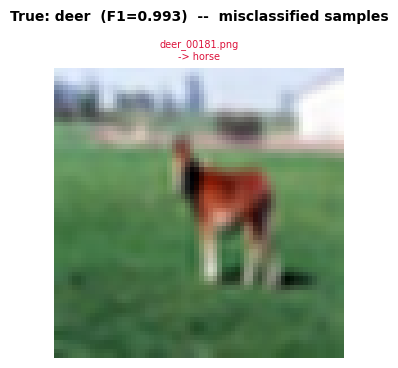


  Class: elephant                      F1=0.9933  errors=1/75
  Confusion row  (total=75):
    OK  elephant                       74x
    XX  bird                            1x



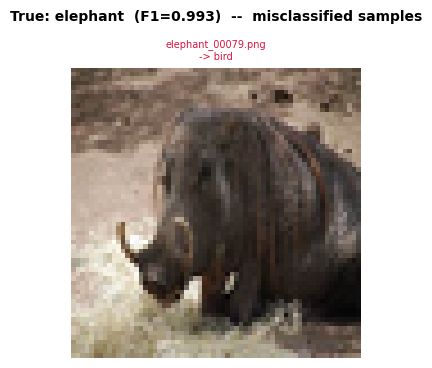


  Class: sheep                         F1=0.9933  errors=1/75
  Confusion row  (total=75):
    OK  sheep                          74x
    XX  horse                           1x



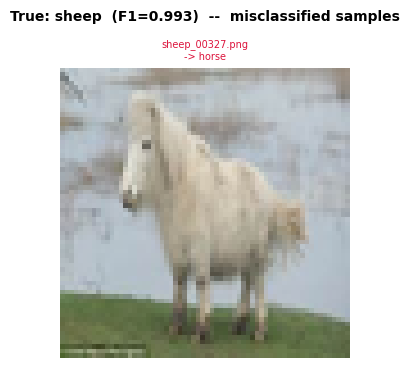


  Class: bird                          F1=0.9934  errors=0/75
  :)  Model got every sample in this class correct!

  Class: frog                          F1=1.0000  errors=0/75
  :)  Model got every sample in this class correct!



In [69]:
# =============================================================================
# ERROR ANALYSIS
# =============================================================================
# Uses the model and hyperparameters from SUBMISSION SETTINGS to run an
# N_FOLDS-fold OOF cross-validation on the full training set, then visualises
# where the model makes mistakes.
#
# Run LOAD DATA and SUBMISSION first.
#
# Leakage handling:
#   USE_FINETUNED=False  ->  full N-fold OOF on frozen features (no leakage).
#   USE_FINETUNED=True   ->  fine-tuned features, but evaluated only on
#                            val_idx_ft (the held-out split from fine-tuning).
#                            The backbone never ran gradient updates on those
#                            images, so their features are clean enough.

import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, classification_report

# max misclassified images to show per class
IMAGES_PER_CLASS = 10


# --- Load the right features -------------------------------------------------

if USE_FINETUNED:
    _ea_path = f'Data\\task1_data\\t1_train_features_ft{feat_suffix}.pt'
    print('[error analysis] Fine-tuned features — eval on val_idx_ft only (no gradient leakage)')
else:
    _ea_path = f'Data\\task1_data\\t1_train_features{feat_suffix}.pt'
    print('[error analysis] Frozen features — full N-fold OOF')

_ea_data    = torch.load(_ea_path, weights_only=False)
ea_features = np.asarray(_ea_data['features'])
ea_labels   = np.asarray(_ea_data['labels'].numpy(), dtype=np.int64)


# --- Build class lookups -----------------------------------------------------

class_to_index    = train_data['class_to_index']
index_to_class    = {v: k for k, v in class_to_index.items()}
class_names       = [index_to_class[i] for i in sorted(index_to_class)]
n_classes         = len(class_names)
train_image_paths = train_data['paths']


# --- Rebuild the submission model as a clonable candidate --------------------

def _error_analysis_model():
    if SUBMISSION_MODEL == 'linear':
        return LogisticRegression(max_iter=2000, random_state=42)
    if SUBMISSION_MODEL == 'svm':
        return SVC(decision_function_shape='ovr', random_state=42, **SVM_SUBMISSION_PARAMS)
    if SUBMISSION_MODEL == 'knn':
        return KNeighborsClassifier(n_neighbors=KNN_NEIGHBOURS, metric=KNN_DISTANCE_METRIC, n_jobs=-1)
    if SUBMISSION_MODEL == 'xgboost':
        return XGBClassifier(objective='multi:softmax', eval_metric='mlogloss',
                             verbosity=0, random_state=42)
    if SUBMISSION_MODEL == 'lgbm':
        return LGBMClassifier(**LIGHTGBM_SUBMISSION_PARAMS, random_state=42, n_jobs=-1)
    if SUBMISSION_MODEL == 'catboost':
        return CatBoostClassifier(**CATBOOST_SUBMISSION_PARAMS, random_seed=42, verbose=0)
    if SUBMISSION_MODEL == 'mlp':
        return {'type': 'mlp', 'hidden': MLP_SUBMISSION_HIDDEN_LAYERS,
                'dropout': MLP_SUBMISSION_DROPOUT_RATE, 'lr': MLP_SUBMISSION_LEARNING_RATE,
                'activation': MLP_ACTIVATION}
    raise ValueError(f'Unknown SUBMISSION_MODEL: {SUBMISSION_MODEL!r}')


model_cand = _error_analysis_model()


# =============================================================================
# EVALUATION  (OOF when frozen, single val-split when fine-tuned)
# =============================================================================

def _fit_predict(tr_i, va_i):
    """Train on tr_i, return predictions on va_i."""
    fold_train_lbl = ea_labels[tr_i]
    fold_val_lbl   = ea_labels[va_i]

    if isinstance(model_cand, dict) and model_cand.get('type') == 'mlp':
        p = model_cand
        model, met = train_multilayer_perceptron(
            ea_features[tr_i].astype(np.float32), fold_train_lbl,
            ea_features[va_i].astype(np.float32), fold_val_lbl,
            hidden_layers = p['hidden'],
            activation    = p.get('activation', nn.ReLU),
            dropout       = p.get('dropout',    0.0),
            learning_rate = p.get('lr',         1e-3),
        )
        model.eval()
        dev = next(model.parameters()).device
        with torch.no_grad():
            preds = model(
                torch.tensor(ea_features[va_i].astype(np.float32)).to(dev)
            ).argmax(1).cpu().numpy()
    else:
        m = clone(model_cand)
        m.fit(np.asarray(ea_features[tr_i]), np.asarray(fold_train_lbl))
        preds = m.predict(np.asarray(ea_features[va_i]))

    return preds


if USE_FINETUNED:
    # Single split — val_idx_ft had no gradient updates during fine-tuning
    print(f'Error analysis  model={SUBMISSION_MODEL}  (fine-tune val split  n={len(val_idx_ft)})')

    preds        = _fit_predict(train_idx_ft, val_idx_ft)
    eval_idx     = val_idx_ft          # indices into ea_features / train_image_paths
    eval_labels  = ea_labels[val_idx_ft]
    eval_preds   = preds
    split_label  = f'val split  n={len(val_idx_ft)}'

    val_f1  = f1_score(eval_labels, eval_preds, average='weighted', zero_division=0)
    val_acc = accuracy_score(eval_labels, eval_preds)
    print(f'  F1={val_f1:.4f}  Acc={val_acc:.4f}')
    oof_f1, oof_acc = val_f1, val_acc

else:
    # Full N-fold OOF on frozen features
    print(f'Error analysis  model={SUBMISSION_MODEL}  folds={N_FOLDS}')

    kfold    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    oof_pred = np.zeros(len(ea_labels), dtype=np.int64)

    for fold_idx, (tr_i, va_i) in enumerate(kfold.split(ea_features, ea_labels)):
        preds          = _fit_predict(tr_i, va_i)
        oof_pred[va_i] = preds
        fold_f1        = f1_score(ea_labels[va_i], preds, average='weighted', zero_division=0)
        print(f'  Fold {fold_idx+1}/{N_FOLDS}  F1={fold_f1:.4f}')

    eval_idx    = np.arange(len(ea_labels))
    eval_labels = ea_labels
    eval_preds  = oof_pred
    split_label = f'{N_FOLDS}-fold OOF'

    oof_f1  = f1_score(eval_labels, eval_preds, average='weighted', zero_division=0)
    oof_acc = accuracy_score(eval_labels, eval_preds)
    print(f'\nOOF ({N_FOLDS}-fold)  F1={oof_f1:.4f}  Acc={oof_acc:.4f}')


# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm      = confusion_matrix(eval_labels, eval_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, vmin=0, vmax=1, linewidths=0.3)

ax.set_title(
    f'{SUBMISSION_MODEL}  --  F1={oof_f1:.4f}  Acc={oof_acc:.4f}  [{split_label}]',
    pad=10,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()


# =============================================================================
# PER-CLASS F1 TABLE
# =============================================================================

report           = classification_report(eval_labels, eval_preds, target_names=class_names,
                                         output_dict=True, zero_division=0)
class_f1s        = [(cls, report[cls]['f1-score']) for cls in class_names]
class_f1s_sorted = sorted(class_f1s, key=lambda x: x[1])   # worst first

print(f'\n{"="*55}')
print('  PER-CLASS F1  (worst -> best)')
print(f'{"="*55}')
print(f'  {"Class":<28}  {"F1":>8}  {"Support":>8}')
print(f'  {"-"*51}')

for cls, f1_val in class_f1s_sorted:
    supp = int(report[cls]['support'])
    print(f'  {cls:<28}  {f1_val:>8.4f}  {supp:>8}')

print()


# =============================================================================
# MISCLASSIFIED IMAGES PER CLASS  (worst first)
# =============================================================================

for cls, class_f1_val in class_f1s_sorted:

    class_idx  = class_to_index[cls]
    wrong_mask = (eval_labels == class_idx) & (eval_preds != class_idx)
    wrong_pos  = np.where(wrong_mask)[0]   # indices into eval_labels / eval_idx

    print(f'{"="*78}')
    print(f'  Class: {cls:<28}  F1={class_f1_val:.4f}  '
          f'errors={len(wrong_pos)}/{int(report[cls]["support"])}')
    print(f'{"="*78}')

    if len(wrong_pos) == 0:
        print('  :)  Model got every sample in this class correct!\n')
        continue

    conf_row = cm[class_idx]
    print(f'  Confusion row  (total={conf_row.sum()}):')
    for other_idx in np.argsort(conf_row)[::-1]:
        if conf_row[other_idx] == 0:
            continue
        marker = 'OK' if other_idx == class_idx else 'XX'
        print(f'    {marker}  {index_to_class[other_idx]:<28}  {conf_row[other_idx]:>3}x')
    print()

    show_pos = wrong_pos[:IMAGES_PER_CLASS]
    n_show   = len(show_pos)
    n_cols   = min(4, n_show)
    n_rows   = math.ceil(n_show / n_cols)

    fig_mc, axes_mc = plt.subplots(
        n_rows, n_cols,
        figsize=(3.2 * n_cols, 3.2 * n_rows + 0.7),
    )

    fig_mc.suptitle(
        f'True: {cls}  (F1={class_f1_val:.3f})  --  misclassified samples',
        fontsize=10, fontweight='bold',
    )

    axes_flat = np.array(axes_mc).flatten() if n_show > 1 else [axes_mc]

    for ax_img, pos in zip(axes_flat, show_pos):
        img_idx  = eval_idx[pos]   # map back to full dataset index
        pred_cls = index_to_class[eval_preds[pos]]
        img_name = os.path.basename(train_image_paths[img_idx])

        ax_img.imshow(Image.open(train_image_paths[img_idx]))
        ax_img.set_title(f'{img_name}\n-> {pred_cls}', fontsize=7, color='crimson')
        ax_img.axis('off')

    for ax_img in axes_flat[n_show:]:
        ax_img.axis('off')

    plt.tight_layout()
    plt.show()
    print()
